In [34]:
# =========================
# PART 2 - VISION TASK
# Brain Tumor MRI Classification

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    BatchNormalization, GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# =========================
# 2. DATASET PATH
# Your folder name is misspelled as "Classifcation"
# Inside it you have "train" and "test"
# =========================

DATASET_PATH = "/content/drive/MyDrive/Brain Tumor Classifcation"

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
TEST_DIR = os.path.join(DATASET_PATH, "test")

print("Dataset exists:", os.path.exists(DATASET_PATH))
print("Train exists:", os.path.exists(TRAIN_DIR))
print("Test exists:", os.path.exists(TEST_DIR))

print("Inside dataset:", os.listdir(DATASET_PATH))
print("Train folders:", os.listdir(TRAIN_DIR))
print("Test folders:", os.listdir(TEST_DIR))

Dataset exists: True
Train exists: True
Test exists: True
Inside dataset: ['train', 'test']
Train folders: ['normal', 'glioma_tumor', 'pituitary_tumor', 'meningioma_tumor']
Test folders: ['normal', 'pituitary_tumor', 'glioma_tumor', 'meningioma_tumor']


In [7]:
# =========================
# 3. DATASET PATH
# =========================

DATASET_PATH = "//content/drive/MyDrive/Brain Tumor Classifcation"

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
TEST_DIR = os.path.join(DATASET_PATH, "test")

print("Dataset exists:", os.path.exists(DATASET_PATH))
print("Train exists:", os.path.exists(TRAIN_DIR))
print("Test exists:", os.path.exists(TEST_DIR))

print("Train folders:", os.listdir(TRAIN_DIR))
print("Test folders:", os.listdir(TEST_DIR))

Dataset exists: True
Train exists: True
Test exists: True
Train folders: ['normal', 'glioma_tumor', 'pituitary_tumor', 'meningioma_tumor']
Test folders: ['normal', 'pituitary_tumor', 'glioma_tumor', 'meningioma_tumor']


In [8]:
# =========================
# 4. REMOVE CORRUPTED IMAGES
# =========================

def remove_corrupted_images(directory):
    corrupted_files = []

    for root, dirs, files in os.walk(directory):
        for file in files:
            file_path = os.path.join(root, file)

            try:
                with Image.open(file_path) as img:
                    img.verify()
            except Exception:
                corrupted_files.append(file_path)

    for file_path in corrupted_files:
        os.remove(file_path)

    print(f"Removed corrupted images from {directory}: {len(corrupted_files)}")
    return corrupted_files


remove_corrupted_images(TRAIN_DIR)
remove_corrupted_images(TEST_DIR)

Removed corrupted images from //content/drive/MyDrive/Brain Tumor Classifcation/train: 0
Removed corrupted images from //content/drive/MyDrive/Brain Tumor Classifcation/test: 0


[]

Training Counts: {'glioma_tumor': 713, 'meningioma_tumor': 723, 'normal': 343, 'pituitary_tumor': 668}
Testing Counts: {'glioma_tumor': 181, 'meningioma_tumor': 183, 'normal': 88, 'pituitary_tumor': 169}
Total Training Images: 2447
Total Testing Images: 621
Total Images: 3068


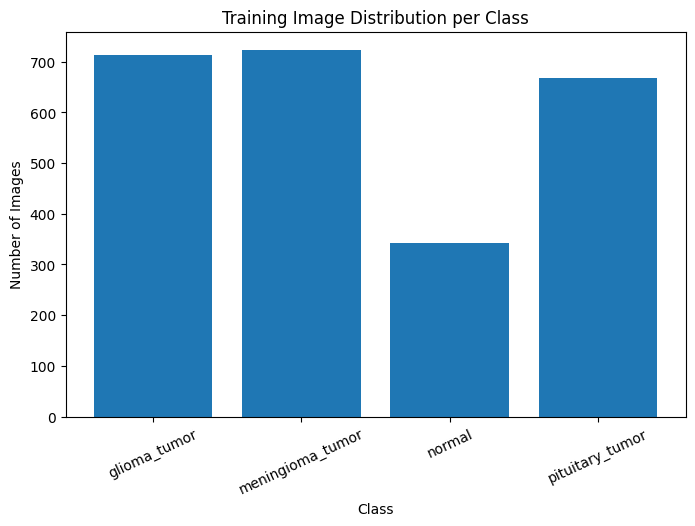

In [9]:
# =========================
# 5. DATASET ANALYSIS
# =========================

classes = sorted(os.listdir(TRAIN_DIR))

train_counts = {}
test_counts = {}

for cls in classes:
    train_counts[cls] = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    test_counts[cls] = len(os.listdir(os.path.join(TEST_DIR, cls)))

print("Training Counts:", train_counts)
print("Testing Counts:", test_counts)

print("Total Training Images:", sum(train_counts.values()))
print("Total Testing Images:", sum(test_counts.values()))
print("Total Images:", sum(train_counts.values()) + sum(test_counts.values()))

plt.figure(figsize=(8, 5))
plt.bar(train_counts.keys(), train_counts.values())
plt.title("Training Image Distribution per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=25)
plt.show()

In [10]:
# =========================
# 6. IMAGE SETTINGS
# =========================

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

In [11]:
# =========================
# 7. DATA PREPROCESSING AND AUGMENTATION
# =========================

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.15,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    shear_range=0.10,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode="nearest"
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [12]:
# =========================
# 8. CREATE TRAIN, VALIDATION, AND TEST GENERATORS
# =========================

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=SEED
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=SEED
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())

print("Class Names:", class_names)
print("Class Indices:", train_generator.class_indices)

Found 2082 images belonging to 4 classes.
Found 365 images belonging to 4 classes.
Found 621 images belonging to 4 classes.
Class Names: ['glioma_tumor', 'meningioma_tumor', 'normal', 'pituitary_tumor']
Class Indices: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'normal': 2, 'pituitary_tumor': 3}


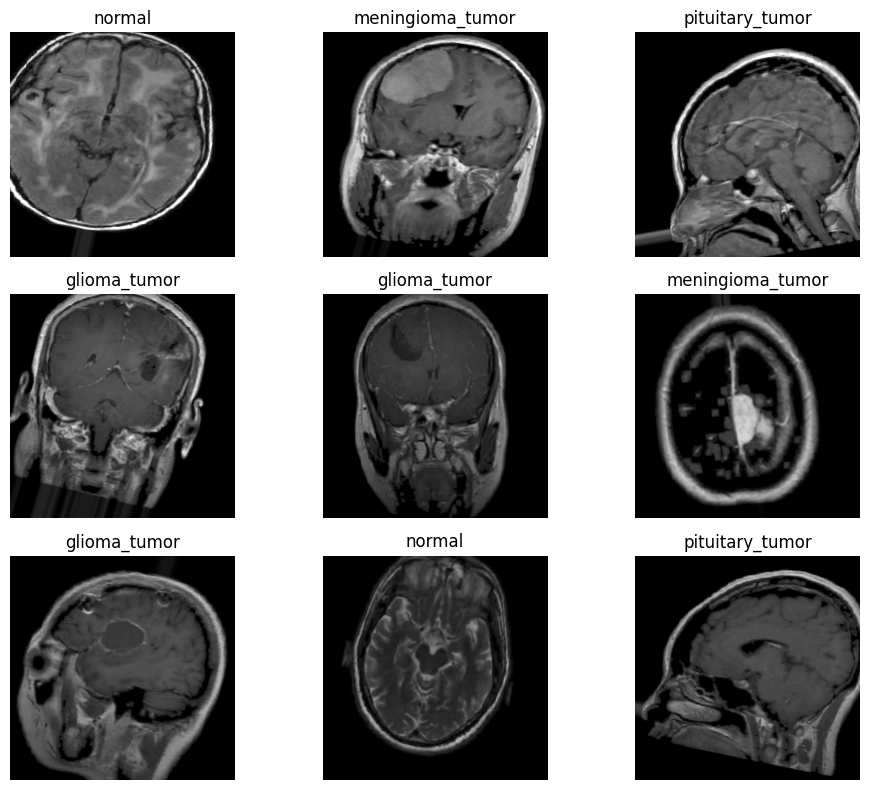

In [13]:
# =========================
# 9. VISUALIZE SAMPLE IMAGES
# =========================

images, labels = next(train_generator)

plt.figure(figsize=(10, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
# =========================
# 10. CLASS WEIGHTS FOR IMBALANCED DATA
# =========================

y_train = train_generator.classes

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights_array))
print("Class Weights:", class_weights)

Class Weights: {0: np.float64(0.857495881383855), 1: np.float64(0.8463414634146341), 2: np.float64(1.7825342465753424), 3: np.float64(0.9163732394366197)}


In [15]:
# =========================
# 11. CALLBACKS
# =========================

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-6
    )
]

In [16]:
# =========================
# 12. MODEL 1 - BASELINE CNN
# =========================

baseline_model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(224, 224, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    Flatten(),

    Dense(256, activation="relu"),
    Dropout(0.4),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(64, activation="relu"),

    Dense(len(class_names), activation="softmax")
])

baseline_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,286,084 (85.01 MB)

 Trainable params: 22,286,084 (85.01 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# =========================
# 13. TRAIN MODEL 1 - BASELINE CNN
# =========================

start_time = time.time()

history_baseline = baseline_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks
)

baseline_time = time.time() - start_time
print("Baseline Training Time:", baseline_time)

Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 63s 799ms/step - accuracy: 0.2267 - loss: 1.3998 - val_accuracy: 0.2795 - val_loss: 1.3640 - learning_rate: 0.0010
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 45s 679ms/step - accuracy: 0.3329 - loss: 1.3093 - val_accuracy: 0.5151 - val_loss: 1.1365 - learning_rate: 0.0010
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 44s 663ms/step - accuracy: 0.4371 - loss: 1.2083 - val_accuracy: 0.5479 - val_loss: 1.1113 - learning_rate: 0.0010
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 45s 680ms/step - accuracy: 0.4923 - loss: 1.1056 - val_accuracy: 0.5589 - val_loss: 1.0237 - learning_rate: 0.0010
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 45s 682ms/step - accuracy: 0.5235 - loss: 1.0175 - val_accuracy: 0.6055 - val_loss: 0.9705 - learning_rate: 0.0010
Epoch 6/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 44s 668ms/step - accuracy: 0.5543 - loss: 0.9518 - val_accuracy: 0.6630 - val_loss: 0.8618 - learning_rate: 0.0010
Epoch 7/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 49s 736ms/step - accuracy: 0.5884 - loss: 0.

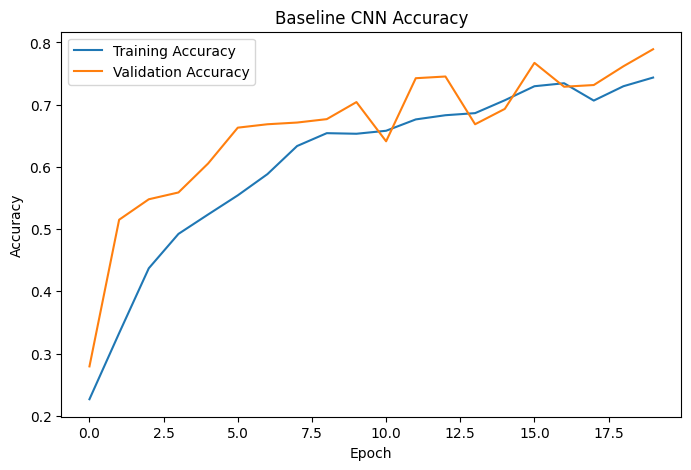

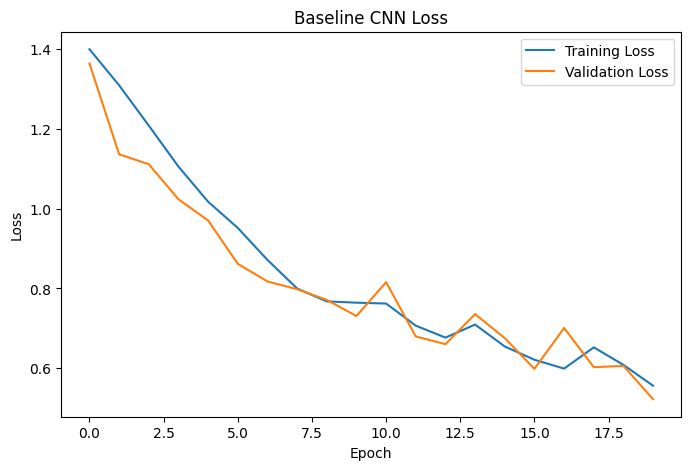

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(history_baseline.history["accuracy"], label="Training Accuracy")
plt.plot(history_baseline.history["val_accuracy"], label="Validation Accuracy")
plt.title("Baseline CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_baseline.history["loss"], label="Training Loss")
plt.plot(history_baseline.history["val_loss"], label="Validation Loss")
plt.title("Baseline CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 176ms/step - accuracy: 0.7424 - loss: 0.6613
Baseline Test Loss: 0.6612513661384583
Baseline Test Accuracy: 0.7423510551452637
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 154ms/step
                  precision    recall  f1-score   support

    glioma_tumor       0.90      0.65      0.76       181
meningioma_tumor       0.74      0.52      0.61       183
          normal       0.75      0.93      0.83        88
 pituitary_tumor       0.66      0.98      0.79       169

        accuracy                           0.74       621
       macro avg       0.76      0.77      0.75       621
    weighted avg       0.77      0.74      0.73       621



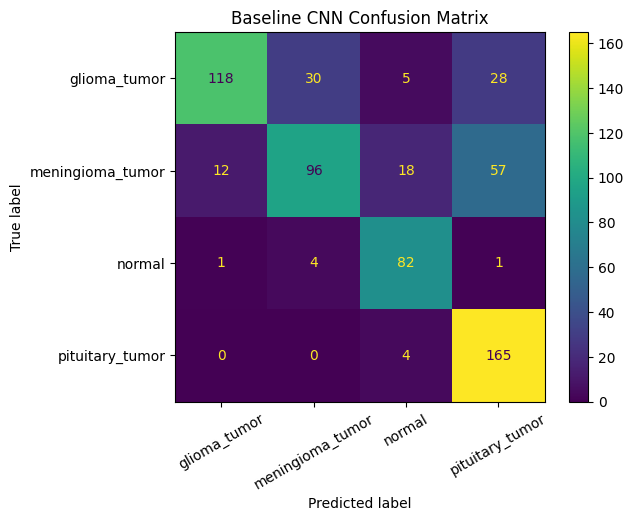

In [19]:
# =========================
# 15. BASELINE CNN EVALUATION
# =========================

baseline_loss, baseline_acc = baseline_model.evaluate(test_generator)

print("Baseline Test Loss:", baseline_loss)
print("Baseline Test Accuracy:", baseline_acc)

y_true = test_generator.classes

baseline_pred_prob = baseline_model.predict(test_generator)
baseline_pred = np.argmax(baseline_pred_prob, axis=1)

print(classification_report(y_true, baseline_pred, target_names=class_names))

cm = confusion_matrix(y_true, baseline_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(xticks_rotation=30)
plt.title("Baseline CNN Confusion Matrix")
plt.show()

In [20]:
# =========================
# 16. MODEL 2 - DEEPER CNN WITH REGULARIZATION
# =========================

deep_model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(256, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(512, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Flatten(),

    Dense(512, activation="relu"),
    Dropout(0.5),

    Dense(256, activation="relu"),
    Dropout(0.4),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(len(class_names), activation="softmax")
])

deep_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

deep_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 10, 10, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 10, 10, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     6,554,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 8,291,396 (31.63 MB)

 Trainable params: 8,289,412 (31.62 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [21]:
# =========================
# 17. TRAIN MODEL 2 - DEEPER CNN
# =========================

start_time = time.time()

history_deep = deep_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks
)

deep_time = time.time() - start_time
print("Deep CNN Training Time:", deep_time)

Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 70s 862ms/step - accuracy: 0.3175 - loss: 2.1524 - val_accuracy: 0.1397 - val_loss: 1.7126 - learning_rate: 1.0000e-04
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 45s 686ms/step - accuracy: 0.3689 - loss: 1.5136 - val_accuracy: 0.1397 - val_loss: 2.9148 - learning_rate: 1.0000e-04
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 46s 700ms/step - accuracy: 0.3814 - loss: 1.3698 - val_accuracy: 0.1397 - val_loss: 3.9822 - learning_rate: 1.0000e-04
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 44s 668ms/step - accuracy: 0.4188 - loss: 1.2616 - val_accuracy: 0.1397 - val_loss: 3.0499 - learning_rate: 2.0000e-05
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 51s 774ms/step - accuracy: 0.4366 - loss: 1.2217 - val_accuracy: 0.2658 - val_loss: 2.1845 - learning_rate: 2.0000e-05
Deep CNN Training Time: 258.3959698677063


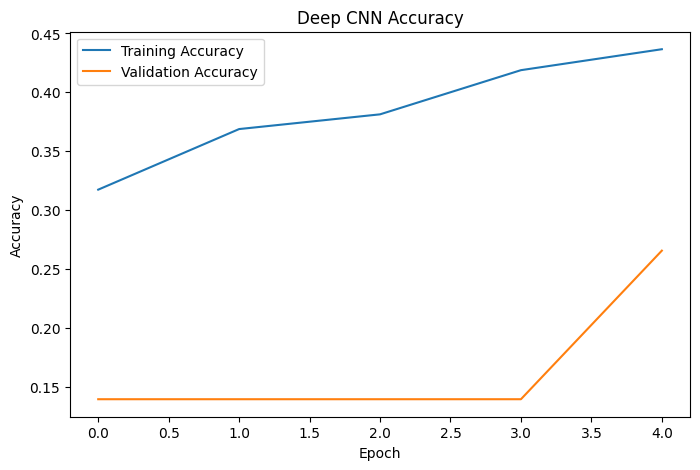

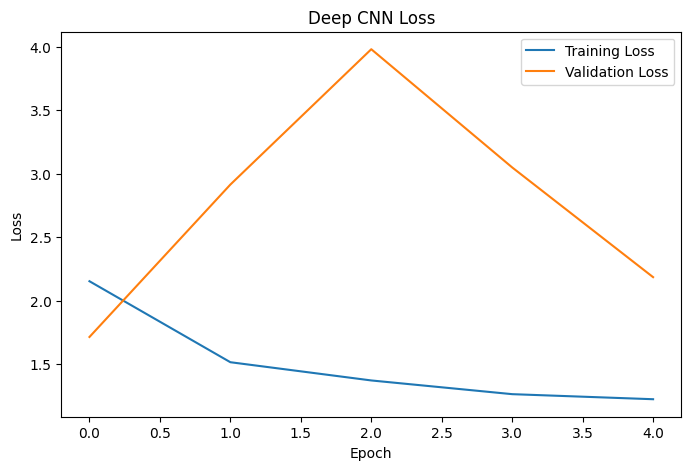

In [22]:
# =========================
# 18. DEEP CNN GRAPHS
# =========================

plt.figure(figsize=(8, 5))
plt.plot(history_deep.history["accuracy"], label="Training Accuracy")
plt.plot(history_deep.history["val_accuracy"], label="Validation Accuracy")
plt.title("Deep CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_deep.history["loss"], label="Training Loss")
plt.plot(history_deep.history["val_loss"], label="Validation Loss")
plt.title("Deep CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 200ms/step - accuracy: 0.1417 - loss: 1.7122
Deep CNN Test Loss: 1.7121635675430298
Deep CNN Test Accuracy: 0.1417069286108017
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 123ms/step
                  precision    recall  f1-score   support

    glioma_tumor       0.00      0.00      0.00       181
meningioma_tumor       0.00      0.00      0.00       183
          normal       0.14      1.00      0.25        88
 pituitary_tumor       0.00      0.00      0.00       169

        accuracy                           0.14       621
       macro avg       0.04      0.25      0.06       621
    weighted avg       0.02      0.14      0.04       621



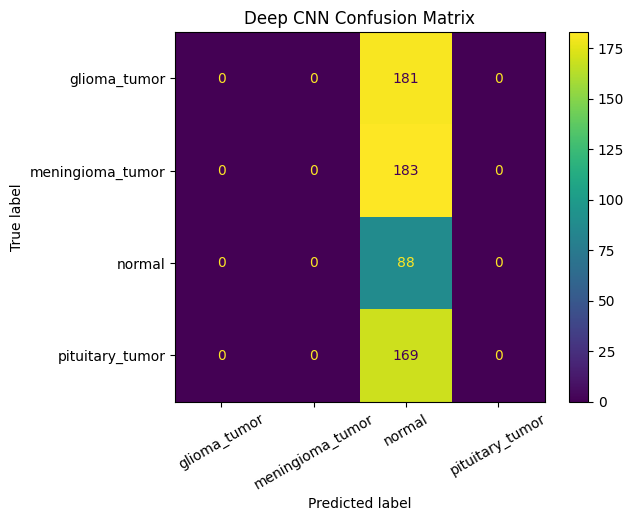

In [24]:
# # =========================
# # 19. DEEP CNN EVALUATION
# # =========================

# deep_loss, deep_acc = deep_model.evaluate(test_generator)

# print("Deep CNN Test Loss:", deep_loss)
# print("Deep CNN Test Accuracy:", deep_acc)

# deep_pred_prob = deep_model.predict(test_generator)
# deep_pred = np.argmax(deep_pred_prob, axis=1)

# print(classification_report(y_true, deep_pred, target_names=class_names))

# cm = confusion_matrix(y_true, deep_pred)

# disp = ConfusionMatrixDisplay(
#     confusion_matrix=cm,
#     display_labels=class_names
# )

# disp.plot(xticks_rotation=30)
# plt.title("Deep CNN Confusion Matrix")
# plt.show()
# =========================
# 19. DEEP CNN EVALUATION
# =========================

deep_loss, deep_acc = deep_model.evaluate(test_generator)

print("Deep CNN Test Loss:", deep_loss)
print("Deep CNN Test Accuracy:", deep_acc)

test_generator.reset()  # <-- Fix: reset before predicting
deep_pred_prob = deep_model.predict(test_generator)
deep_pred = np.argmax(deep_pred_prob, axis=1)

print(classification_report(y_true, deep_pred, target_names=class_names, zero_division=0))  # <-- Fix: zero_division=0

cm = confusion_matrix(y_true, deep_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(xticks_rotation=30)
plt.title("Deep CNN Confusion Matrix")
plt.show()

In [25]:
# =========================
# 20. OPTIMIZER COMPARISON - DEEP CNN WITH SGD
# =========================

deep_sgd_model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(256, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(512, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Flatten(),

    Dense(512, activation="relu"),
    Dropout(0.5),

    Dense(256, activation="relu"),
    Dropout(0.4),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(len(class_names), activation="softmax")
])

deep_sgd_model.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

deep_sgd_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 10, 10, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 10, 10, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 5, 5, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │     6,554,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 8,291,396 (31.63 MB)

 Trainable params: 8,289,412 (31.62 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [26]:
# =========================
# 21. TRAIN DEEP CNN WITH SGD
# =========================

start_time = time.time()

history_deep_sgd = deep_sgd_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks
)

deep_sgd_time = time.time() - start_time
print("Deep CNN SGD Training Time:", deep_sgd_time)

Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 61s 788ms/step - accuracy: 0.2719 - loss: 2.7913 - val_accuracy: 0.2904 - val_loss: 1.3738 - learning_rate: 0.0100
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 48s 721ms/step - accuracy: 0.2733 - loss: 1.4205 - val_accuracy: 0.2904 - val_loss: 1.3838 - learning_rate: 0.0100
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 44s 664ms/step - accuracy: 0.2704 - loss: 1.4155 - val_accuracy: 0.3205 - val_loss: 1.3603 - learning_rate: 0.0100
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 44s 667ms/step - accuracy: 0.2695 - loss: 1.3973 - val_accuracy: 0.2959 - val_loss: 1.3718 - learning_rate: 0.0020
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 47s 716ms/step - accuracy: 0.2920 - loss: 1.3937 - val_accuracy: 0.2932 - val_loss: 1.3746 - learning_rate: 0.0020
Deep CNN SGD Training Time: 244.5090365409851


In [27]:
# =========================
# 22. EVALUATE DEEP CNN WITH SGD
# =========================

sgd_loss, sgd_acc = deep_sgd_model.evaluate(test_generator)

print("Deep CNN SGD Test Loss:", sgd_loss)
print("Deep CNN SGD Test Accuracy:", sgd_acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 220ms/step - accuracy: 0.2915 - loss: 1.3739
Deep CNN SGD Test Loss: 1.3739229440689087
Deep CNN SGD Test Accuracy: 0.2914653718471527


In [28]:
# =========================
# 23. ABLATION STUDY - DEEP CNN WITHOUT DROPOUT
# =========================

ablation_model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(256, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(512, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Flatten(),

    Dense(512, activation="relu"),
    Dense(256, activation="relu"),
    Dense(128, activation="relu"),

    Dense(len(class_names), activation="softmax")
])

ablation_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

ablation_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 10, 10, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 10, 10, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 5, 5, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │     6,554,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,291,396 (31.63 MB)

 Trainable params: 8,289,412 (31.62 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [29]:
# =========================
# 24. TRAIN ABLATION MODEL
# =========================

start_time = time.time()

history_ablation = ablation_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks
)

ablation_time = time.time() - start_time
print("Ablation Model Training Time:", ablation_time)

Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 63s 807ms/step - accuracy: 0.4938 - loss: 1.1832 - val_accuracy: 0.1397 - val_loss: 1.6588 - learning_rate: 1.0000e-04
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 44s 672ms/step - accuracy: 0.6153 - loss: 0.8774 - val_accuracy: 0.1397 - val_loss: 1.8690 - learning_rate: 1.0000e-04
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 44s 666ms/step - accuracy: 0.6873 - loss: 0.7466 - val_accuracy: 0.3562 - val_loss: 1.6206 - learning_rate: 1.0000e-04
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 45s 690ms/step - accuracy: 0.7695 - loss: 0.5584 - val_accuracy: 0.3753 - val_loss: 1.5006 - learning_rate: 2.0000e-05
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 45s 679ms/step - accuracy: 0.7901 - loss: 0.5026 - val_accuracy: 0.3753 - val_loss: 1.5584 - learning_rate: 2.0000e-05
Ablation Model Training Time: 242.37956428527832


In [30]:
# =========================
# 25. EVALUATE ABLATION MODEL
# =========================

ablation_loss, ablation_acc = ablation_model.evaluate(test_generator)

print("Ablation Test Loss:", ablation_loss)
print("Ablation Test Accuracy:", ablation_acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step - accuracy: 0.1417 - loss: 1.6605
Ablation Test Loss: 1.6605218648910522
Ablation Test Accuracy: 0.1417069286108017


In [32]:
# # =========================
# # 26. TRANSFER LEARNING DATA GENERATORS
# # EfficientNetB3 uses preprocess_input
# # =========================

# tl_train_datagen = ImageDataGenerator(
#     preprocessing_function=preprocess_input,
#     validation_split=0.15,
#     rotation_range=20,
#     zoom_range=0.15,
#     width_shift_range=0.10,
#     height_shift_range=0.10,
#     shear_range=0.10,
#     horizontal_flip=True,
#     brightness_range=[0.8, 1.2],
#     fill_mode="nearest"
# )

# tl_test_datagen = ImageDataGenerator(
#     preprocessing_function=preprocess_input
# )

# tl_train_generator = tl_train_datagen.flow_from_directory(
#     TRAIN_DIR,
#     target_size=IMG_SIZE,
#     batch_size=BATCH_SIZE,
#     class_mode="categorical",
#     subset="training",
#     shuffle=True,
#     seed=SEED
# )

# tl_val_generator = tl_train_datagen.flow_from_directory(
#     TRAIN_DIR,
#     target_size=IMG_SIZE,
#     batch_size=BATCH_SIZE,
#     class_mode="categorical",
#     subset="validation",
#     shuffle=False,
#     seed=SEED
# )

# tl_test_generator = tl_test_datagen.flow_from_directory(
#     TEST_DIR,
#     target_size=IMG_SIZE,
#     batch_size=BATCH_SIZE,
#     class_mode="categorical",
#     shuffle=False
# )
tl_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.15,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    shear_range=0.10,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode="nearest"
)

tl_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

tl_train_generator = tl_train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=SEED
)

tl_val_generator = tl_train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=SEED
)

tl_test_generator = tl_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)


Found 2082 images belonging to 4 classes.
Found 365 images belonging to 4 classes.
Found 621 images belonging to 4 classes.


In [35]:
# =========================
# 27. MODEL 3 - TRANSFER LEARNING WITH RESNET50
# =========================

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)

output = Dense(len(class_names), activation="softmax")(x)

resnet_model = Model(
    inputs=base_model.input,
    outputs=output
)

resnet_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,153,860 (92.14 MB)

 Trainable params: 562,052 (2.14 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [36]:
# # =========================
# # 28. PHASE 1 - FEATURE EXTRACTION
# # =========================

# start_time = time.time()

# history_eff_phase1 = efficientnet_model.fit(
#     tl_train_generator,
#     validation_data=tl_val_generator,
#     epochs=15,
#     class_weight=class_weights,
#     callbacks=callbacks
# )

# eff_phase1_time = time.time() - start_time
# print("EfficientNet Phase 1 Training Time:", eff_phase1_time)
start_time = time.time()

history_resnet_phase1 = resnet_model.fit(
    tl_train_generator,
    validation_data=tl_val_generator,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks
)

resnet_phase1_time = time.time() - start_time
print("ResNet50 Phase 1 Training Time:", resnet_phase1_time)


Epoch 1/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 76s 915ms/step - accuracy: 0.6465 - loss: 0.9718 - val_accuracy: 0.7425 - val_loss: 0.6421 - learning_rate: 0.0010
Epoch 2/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 47s 707ms/step - accuracy: 0.7445 - loss: 0.6410 - val_accuracy: 0.8329 - val_loss: 0.4445 - learning_rate: 0.0010
Epoch 3/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 45s 683ms/step - accuracy: 0.7733 - loss: 0.5696 - val_accuracy: 0.8247 - val_loss: 0.4573 - learning_rate: 0.0010
Epoch 4/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 46s 692ms/step - accuracy: 0.7954 - loss: 0.4892 - val_accuracy: 0.8521 - val_loss: 0.3842 - learning_rate: 0.0010
Epoch 5/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 48s 720ms/step - accuracy: 0.8184 - loss: 0.4763 - val_accuracy: 0.8027 - val_loss: 0.4429 - learning_rate: 0.0010
Epoch 6/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 45s 677ms/step - accuracy: 0.8300 - loss: 0.4103 - val_accuracy: 0.8192 - val_loss: 0.4004 - learning_rate: 0.0010
Epoch 7/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 44s 674ms/step - accuracy: 0.8329 - loss: 0.

In [37]:
# # =========================
# # 29. PHASE 2 - FINE TUNING TOP 40%
# # =========================

# base_model.trainable = True

# fine_tune_at = int(len(base_model.layers) * 0.6)

# for layer in base_model.layers[:fine_tune_at]:
#     layer.trainable = False

# for layer in base_model.layers[fine_tune_at:]:
#     layer.trainable = True

# efficientnet_model.compile(
#     optimizer=Adam(learning_rate=1e-5),
#     loss="categorical_crossentropy",
#     metrics=["accuracy"]
# )

# start_time = time.time()

# history_eff_phase2 = efficientnet_model.fit(
#     tl_train_generator,
#     validation_data=tl_val_generator,
#     epochs=20,
#     class_weight=class_weights,
#     callbacks=callbacks
# )

# eff_phase2_time = time.time() - start_time
# print("EfficientNet Phase 2 Training Time:", eff_phase2_time)
base_model.trainable = True

fine_tune_at = int(len(base_model.layers) * 0.6)

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

resnet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

start_time = time.time()

history_resnet_phase2 = resnet_model.fit(
    tl_train_generator,
    validation_data=tl_val_generator,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks
)

resnet_phase2_time = time.time() - start_time
print("ResNet50 Phase 2 Training Time:", resnet_phase2_time)



Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.8199 - loss: 0.4431 - val_accuracy: 0.8740 - val_loss: 0.3482 - learning_rate: 1.0000e-05
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 46s 690ms/step - accuracy: 0.8463 - loss: 0.3745 - val_accuracy: 0.8740 - val_loss: 0.2924 - learning_rate: 1.0000e-05
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 46s 701ms/step - accuracy: 0.8626 - loss: 0.3157 - val_accuracy: 0.8877 - val_loss: 0.3052 - learning_rate: 1.0000e-05
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 50s 747ms/step - accuracy: 0.8732 - loss: 0.2915 - val_accuracy: 0.8877 - val_loss: 0.3158 - learning_rate: 1.0000e-05
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 45s 684ms/step - accuracy: 0.8876 - loss: 0.2825 - val_accuracy: 0.8767 - val_loss: 0.3528 - learning_rate: 1.0000e-05
Epoch 6/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 45s 682ms/step - accuracy: 0.9039 - loss: 0.2467 - val_accuracy: 0.8740 - val_loss: 0.3404 - learning_rate: 2.0000e-06
Epoch 7/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 46s 698ms/step - accur

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 128ms/step - accuracy: 0.8889 - loss: 0.3090
ResNet50 Test Loss: 0.3090471029281616
ResNet50 Test Accuracy: 0.8888888955116272
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 360ms/step
                  precision    recall  f1-score   support

    glioma_tumor       0.93      0.86      0.89       181
meningioma_tumor       0.84      0.83      0.83       183
          normal       0.95      0.90      0.92        88
 pituitary_tumor       0.87      0.99      0.93       169

        accuracy                           0.89       621
       macro avg       0.90      0.89      0.89       621
    weighted avg       0.89      0.89      0.89       621



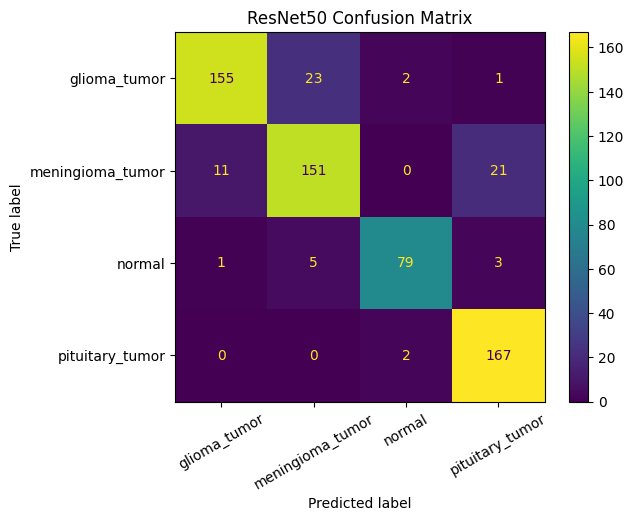

In [38]:
# =========================
# 30. RESNET50 EVALUATION
# =========================

resnet_loss, resnet_acc = resnet_model.evaluate(tl_test_generator)

print("ResNet50 Test Loss:", resnet_loss)
print("ResNet50 Test Accuracy:", resnet_acc)

y_true_tl = tl_test_generator.classes

resnet_pred_prob = resnet_model.predict(tl_test_generator)
resnet_pred = np.argmax(resnet_pred_prob, axis=1)

print(classification_report(
    y_true_tl,
    resnet_pred,
    target_names=class_names
))

cm = confusion_matrix(y_true_tl, resnet_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(xticks_rotation=30)
plt.title("ResNet50 Confusion Matrix")
plt.show()

In [39]:
# =========================
# 31. FINAL MODEL COMPARISON TABLE
# =========================

results_df = pd.DataFrame({
    "Model": [
        "Baseline CNN",
        "Deep CNN Adam",
        "Deep CNN SGD",
        "Ablation No Dropout",
        "ResNet50"
    ],
    "Test Accuracy": [
        baseline_acc,
        deep_acc,
        sgd_acc,
        ablation_acc,
        resnet_acc
    ],
    "Training Time Seconds": [
        baseline_time,
        deep_time,
        deep_sgd_time,
        ablation_time,
        resnet_phase1_time + resnet_phase2_time
    ]
})

print(results_df)


                 Model  Test Accuracy  Training Time Seconds
0         Baseline CNN       0.742351             906.663304
1        Deep CNN Adam       0.141707             258.395970
2         Deep CNN SGD       0.291465             244.509037
3  Ablation No Dropout       0.141707             242.379564
4             ResNet50       0.888889            1000.044080


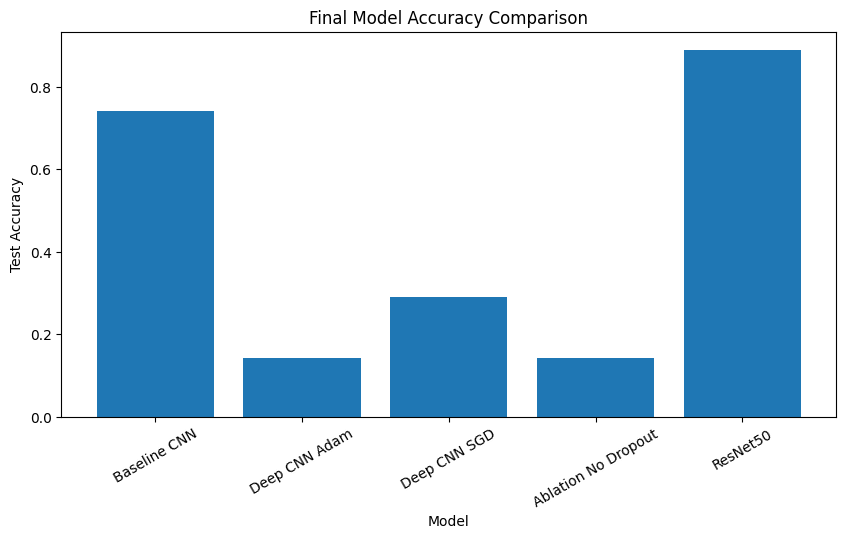

In [40]:
# =========================
# 32. FINAL MODEL ACCURACY COMPARISON GRAPH
# =========================
plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["Test Accuracy"])
plt.title("Final Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.xticks(rotation=30)
plt.show()

In [41]:
# =========================
# 33. SAVE ALL MODELS
# =========================

baseline_model.save("/content/baseline_cnn_brain_tumor.h5")
deep_model.save("/content/deep_cnn_brain_tumor.h5")
resnet_model.save("/content/resnet50_brain_tumor.h5")

print("All models saved successfully.")

All models saved successfully.
